<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Transformers%20Alapok%20Attention%20Mechanizmus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

© 2025 by Barbara Noémi Szabó is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# Transformer alapok
## Szekvencia-szekvencia (Sequence-to-Sequence)

Néha szekvenciális adatokat szeretnénk feldolgozni: a szekvencia elemei időbeli információt hordoznak, vagyis a bemenet sorrendje számít. 4 típusú szekvencia-szekvencia modellezés létezik:

* Egy-a-többhöz (One to many): Egyetlen bemenet kimenetek sorozatát állítja elő
  * pl. képfeliratozás
* Több-az-egyhez (Many to one): Bemenetek sorozata egyetlen kimenetet állít elő
  * pl. szentimentelemzés
* Több-a-többhöz igazított (Many to many aligned): Bemenetek sorozata azonos hosszúságú kimenetek sorozatát állítja elő
  * pl. videó képkockák osztályozása
* Több-a-többhöz nem igazított (Many to many unaligned): Bemenetek sorozata eltérő hosszúságú kimenetek sorozatát állítja elő
  * pl. fordítás

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/seq2seq.png" width="800">

[forrás](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)

In [ ]:
!pip install -qq gensim

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api
import time
from math import sin, cos
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random
import os
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

!wget https://www.manythings.org/anki/hun-eng.zip
!unzip hun-eng.zip
!rm hun-eng.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.4 MB/s eta 0:00:00
--2026-01-19 22:00:20--  https://www.manythings.org/anki/hun-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4407185 (4.2M) [application/zip]
Saving to: ‘hun-eng.zip’

hun-eng.zip         100%[===================>]   4.20M  --.-KB/s    in 0.1s    

2026-01-19 22:00:20 (32.4 MB/s) - ‘hun-eng.zip’ saved [4407185/4407185]

Archive:  hun-eng.zip
  inflating: _about.txt              
  inflating: hun.txt                 


## Transformer

A Transformer egy 2017-es mélytanulási modell-architektúra, amelyet eredetileg nyelvi fordításra terveztek. Két részből áll:
* Az Enkóder (Encoder)
  * bemenetként kapja a tokenizált forrásnyelvű szöveget és
  * előállítja a teljes bemeneti szöveg vektoros reprezentációját (ez tekinthető szövegbeágyazásnak – vegyük észre, hogy eddig csak szavak beágyazását vizsgáltuk külön-külön, nem teljes szövegekét).
* A Dekóder (Decoder)
  * bemenetként kapja a bemeneti szöveg beágyazását és a lefordított mondat első néhány tokenizált szavát, és
  * kimenetként egy valószínűségi eloszlást ad a célnyelv szókincse felett a lefordított mondat következő szavának (tokenjének) előrejelzéséhez.
    * Ez azt jelenti, hogy auto-regresszív modell, vagyis a teljes mondat generálásához az előző kimenetet kell betáplálnunk, és azt használjuk a következő szó generálásához. A generálás akkor áll le, amikor elérjük a maximális hosszúságot, vagy a generált token az \<EOS\> jelző (End Of Sentence - Mondat vége). A generálás megkezdéséhez először az \<SOS\> (Start Of Sentence - Mondat eleje) speciális tokent tápláljuk be, így nem kell kitalálnunk a mondat első szavát. A tokenizált tanító adatokban szintén hozzáadunk egy \<SOS\> és egy \<EOS\> tokent minden mondat elejéhez és végéhez.

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/transformer_architecture.png" width="400">

### Projekció és Softmax

Egy lineáris réteget használunk a végén, hogy az előző rejtett réteg kimenetét (ezt a transformer modell dimenziójának nevezzük) átalakítsuk a szókincs dimenziójára – ezeket `logits`-nak nevezzük. Ezután a Softmax függvényt használjuk a logits-ok valószínűségi eloszlássá alakításához.

$\frac{e^{1.3}}{e^{1.3} + e^{5.1} + e^{2.2} + e^{0.7} + e^{1.1}} \approx 0.02 $

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/softmax.png" height="300">
<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/exp.png" height="300">

In [ ]:
def softmax(logits: torch.Tensor) -> torch.Tensor:
    norm = (torch.exp(logits)).sum(dim=1)
    norm = norm.unsqueeze(dim=1)

    probabilities = torch.exp(logits) / norm

    return torch.round(probabilities, decimals=2)

In [ ]:
logits = torch.tensor([[1.3, 5.1, 2.2, 0.7, 1.1], [1.3, 5.1, 2.2, 0.7, 1.1]])
softmax(logits)

tensor([[0.0200, 0.9000, 0.0500, 0.0100, 0.0200],
        [0.0200, 0.9000, 0.0500, 0.0100, 0.0200]])

### Mátrixszorzás

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/matrix_mul.png" height="300">

### Beágyazások (Embeddings)

A modell első komponense a beágyazási réteg, amely a tokenek kódolására szolgál. A tanítás során a modell saját beágyazásokat tanul minden tokenhez – nem használunk előtanított beágyazásokat (ezért a bemenet egyszerűen a tokenek azonosítói).

In [ ]:
vocab_size = 5
embedding_dim = 3
embeddings = torch.nn.Embedding(vocab_size, embedding_dim)

embeddings.weight.detach()

tensor([[-0.4916, -0.0816, -1.3842],
        [-0.8910,  1.3161, -0.7697],
        [ 0.3369, -1.2044,  0.6703],
        [-1.6274,  1.3193,  0.0844],
        [-0.1189,  0.2597, -1.4748]])

In [ ]:
token_ids = torch.tensor([0, 1, 4, 2])
embeddings(token_ids).detach()

tensor([[-0.4916, -0.0816, -1.3842],
        [-0.8910,  1.3161, -0.7697],
        [-0.1189,  0.2597, -1.4748],
        [ 0.3369, -1.2044,  0.6703]])

In [ ]:
token_ids = torch.tensor([0, 1, 4, 2])
embeddings(token_ids).detach().T

tensor([[-0.4916, -0.8910, -0.1189,  0.3369],
        [-0.0816,  1.3161,  0.2597, -1.2044],
        [-1.3842, -0.7697, -1.4748,  0.6703]])

### Skálázott skaláris szorzat figyelem (Scaled Dot-Product Attention)

$\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$

Intuíció:

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/attention_intuition.png" width="600">

A célunk a beágyazások módosítása a kontextus felhasználásával. A `macska` egyszerű beágyazása helyett tudjuk, hogy "a fekete macska", és olyan beágyazást szeretnénk, amely az összes információt kódolja – ezt jelöli a képen a `macska'`.

In [ ]:
def plot_similarities(similarities, labels, title=None):
    # Mátrix ábrázolása
    plt.figure(figsize=(6, 5))
    sns.heatmap(similarities, annot=True, cmap="Blues", xticklabels=labels, yticklabels=labels)
    if title is not None:
        plt.title(title)
    plt.show()

In [ ]:
# 3 millió Word2Vec vektor betöltése, amelyeket a Google híreken tanítottak, mindegyik 300 dimenziós.
# Ez a modell néhány percig tölthet be.

start_time = time.time()
w2v_google = api.load("word2vec-google-news-300")
print("--- %s másodperc ---" % (time.time() - start_time))

[==================================================] 100.0% 1662.8/1662.8MB downloaded
--- 227.40816164016724 másodperc ---


In [ ]:
words = ["the", "cat", "is", "black"]
N = len(words)

QUERIES = torch.tensor(np.array([w2v_google[word] for word in words]))  # (N, 300) - Lekérdezések
KEYS = torch.tensor(np.array([w2v_google[word] for word in words]))     # (N, 300) - Kulcsok
VALUES = torch.tensor(np.array([w2v_google[word] for word in words]))   # (N, 300) - Értékek

QUERIES.size()

torch.Size([4, 300])

Először megpróbáljuk kideríteni, melyek a releváns szavak a kontextusból minden szóhoz – ehhez kiszámítjuk a skaláris szorzatokat minden párra.

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/similarity.png" width="400">

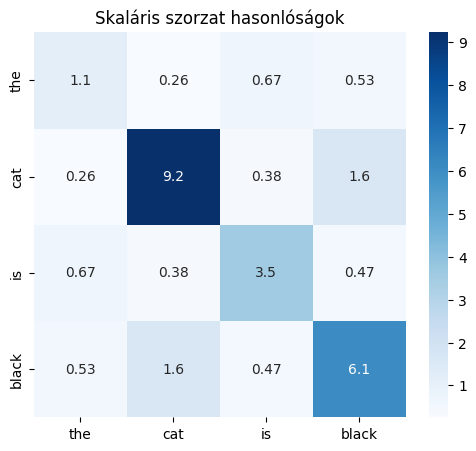

In [ ]:
# similarities = QUERIES @ KEYS.T

similarities = torch.zeros(size=(N, N))

for i, query in enumerate(QUERIES):
    for j, key in enumerate(KEYS):
        prod = query*key
        dot_prod = prod.sum()

        similarities[i,j] = dot_prod

plot_similarities(similarities, words, title="Skaláris szorzat hasonlóságok")

In [ ]:
scaled_similarities = similarities / (300**0.5)

print("Beágyazás szórása:\t\t", QUERIES.std(dim=1))
print("Skaláris szorzat szórása:\t\t", similarities.std(dim=1))
print("Skálázott skaláris szorzat szórása:\t", scaled_similarities.std(dim=1))

Beágyazás szórása:		 tensor([0.0619, 0.1756, 0.1080, 0.1423])
Skaláris szorzat szórása:		 tensor([0.3731, 4.2803, 1.5227, 2.6436])
Skálázott skaláris szorzat szórása:	 tensor([0.0215, 0.2471, 0.0879, 0.1526])


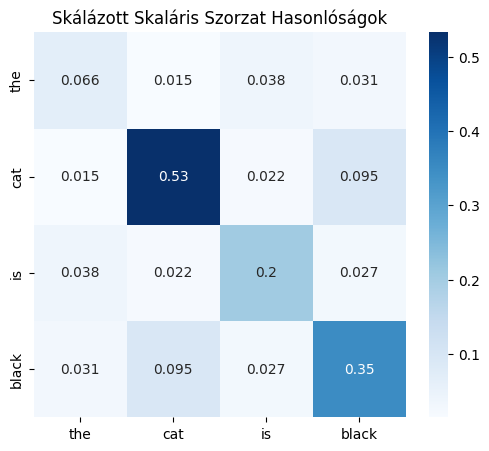

In [ ]:
plot_similarities(scaled_similarities, words, title="Skálázott Skaláris Szorzat Hasonlóságok")

Most a hasonlóságokat súlyokká alakítjuk úgy, hogy a hasonlóbb párok nagyobb súlyt kapjanak – ehhez a Softmax függvényt alkalmazzuk minden sorra.

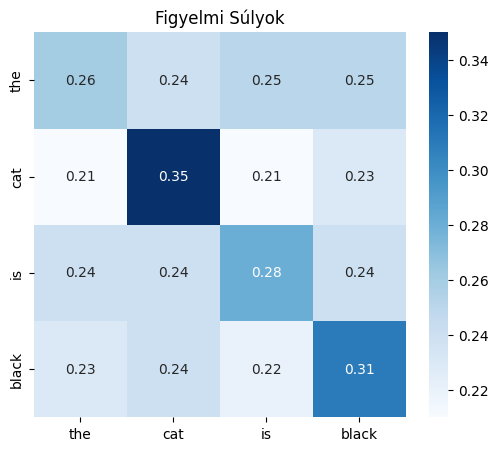

In [ ]:
weights = softmax(scaled_similarities)
plot_similarities(weights, words, title="Figyelmi Súlyok")

Most itt az ideje a súlyok felhasználásának az új beágyazások kialakításához: minden új beágyazás az összes beágyazás súlyozott összege:

`the' = w_1 * the + w_2 * cat + w_3 * is + w_4 * black`

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/values.png" width="600">

In [ ]:
# output = weights @ VALUES

output = torch.zeros(size=(N, 300))

for i, weight in enumerate(weights):
    weighted_sum = (weight.unsqueeze(dim=1) * VALUES).sum(dim=0)
    output[i] = weighted_sum

output.size()

torch.Size([4, 300])

### Önfigyelem (Self-Attention)

A Key (Kulcs), Query (Lekérdezés) és Value (Érték) vektorok ugyanazokból a beágyazásokból származnak, és különböző lineáris rétegekkel transzformáljuk őket.

In [ ]:
words = ["the", "quick", "brown", "fox", "jumps", "over", "lazy", "dog"]
embeddings = torch.tensor([w2v_google[word] for word in words])

embeddings.size()

/tmp/ipython-input-847016099.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  embeddings = torch.tensor([w2v_google[word] for word in words])


torch.Size([8, 300])

In [ ]:
K = torch.nn.Linear(300, 300)
Q = torch.nn.Linear(300, 300)
V = torch.nn.Linear(300, 300)

In [ ]:
def SelfAttention(K, Q, V, embeddings):
    key = K(embeddings)
    query = Q(embeddings)
    value = V(embeddings)

    batch_size, d_k = key.size()

    scaled_similarities = (query @ key.T) / (d_k**0.5)
    weights = softmax(scaled_similarities)

    return weights @ value

output = SelfAttention(K, Q, V, embeddings)
output.size()

torch.Size([8, 300])

Így a beágyazásokat a környező beágyazások felhasználásával tudjuk transzformálni.

### Kereszt-figyelem (Cross-Attention)

A kereszt-figyelem egy híd, amely összeköti az enkódert és a dekódert. Az enkóder összefoglalja a bemenetet, a dekóder pedig ezt az információt használja a végső kimenet előállításához.

Ebben a folyamatban:
- A **kulcsok (keys)** és **értékek (values)** az enkóder kimenete, amelyek a bemenet összes fontos részletét tartalmazzák.
- A **lekérdezés (query)** a dekóder előző rétegéből származik, és azt kérdezi: "A teljes szekvencia melyik részére figyeljek most?"

Más szóval, ez segít a dekódernek eldönteni, hogy az enkóder kimenetének mely részei a legrelevánsabbak a szekvencia következő szavának generálásához.

### Többfejű figyelem (Multi-Head Attention)

Egyetlen figyelemmechanizmus helyett a modell több figyelemfejet alkalmaz párhuzamosan. Minden fej független lekérdezés, kulcs és érték projekciókat hajt végre tanult súlyokkal. Az összes fej kimenetét összefűzzük (konkatenáljuk), majd újra projektáljuk.

A figyelem több fejre osztása lehetővé teszi, hogy a modell a bemenet különböző aspektusaira koncentráljon.

In [ ]:
class MultiHeadAttentionExample(torch.nn.Module):
    def __init__(self, embed_size, num_heads):
        super(MultiHeadAttentionExample, self).__init__()
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        assert (
            self.head_dim * num_heads == embed_size
        ), "Embedding size must be divisible by the number of heads"

        self.query = torch.nn.Linear(embed_size, embed_size)
        self.key = torch.nn.Linear(embed_size, embed_size)
        self.value = torch.nn.Linear(embed_size, embed_size)

        # Final linear layer after concatenating heads
        self.fc_out = torch.nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, queries):
        batch_size = queries.size()[0]
        query_len, key_len, value_len = queries.size()[1], keys.size()[1], values.size()[1]

        queries = self.query(queries)  # (batch_size, query_len, embed_size)
        keys = self.key(keys)          # (batch_size, key_len, embed_size)
        values = self.value(values)    # (batch_size, value_len, embed_size)

        # Split embeddings for each head
        queries = queries.view(batch_size, query_len, self.num_heads, self.head_dim)
        keys = keys.view(batch_size, key_len, self.num_heads, self.head_dim)
        values = values.view(batch_size, value_len, self.num_heads, self.head_dim)

        # Scaled Dot-Product Attention
        queries = queries.transpose(1, 2)  # (batch_size, num_heads, query_len, head_dim)
        keys = keys.transpose(1, 2)        # (batch_size, num_heads, key_len, head_dim)
        values = values.transpose(1, 2)    # (batch_size, num_heads, value_len, head_dim)

        similarities = torch.matmul(queries, keys.transpose(-1, -2)) / (self.head_dim ** 0.5)
        attention_weights = torch.softmax(similarities, dim=-1)  # (batch_size, num_heads, query_len, key_len)

        out = torch.matmul(attention_weights, values)  # (batch_size, num_heads, query_len, head_dim)

        # Concatenate heads
        out = out.transpose(1, 2).contiguous()  # (batch_size, query_len, num_heads, head_dim)
        out = out.view(batch_size, query_len, -1)  # (batch_size, query_len, embed_size)

        out = self.fc_out(out)  # (batch_size, query_len, embed_size)
        return out

In [ ]:
embed_size = 8
num_heads = 2
multi_head_attention = MultiHeadAttentionExample(embed_size, num_heads)

# Véletlenszerű bemenet
batch_size, seq_len = 1, 3
values = torch.rand(batch_size, seq_len, embed_size)
keys = torch.rand(batch_size, seq_len, embed_size)
queries = torch.rand(batch_size, seq_len, embed_size)

output = multi_head_attention(values, keys, queries)
output.size()

torch.Size([1, 3, 8])

### Pozíciókódolás (Positional Encoding)

A szavak sorrendjét szeretnénk felhasználni a szekvenciában, mert számít, hogy "A kutya kergette a macskát." vagy "A macska kergette a kutyát.". A következő képletet használjuk a pozíciók kódolásához:

$\text{PE}_{(pos,2i)} = \sin{(pos/10000^{2i/d_{\text{model}}​})}$

$\text{PE}_{(pos,2i+1)} = \cos{(pos/10000^{2i/d_{\text{model}}})}$

ahol
* $pos$ = token pozíció
* $i$ = beágyazási dimenzió index
* $d_{model}$ = beágyazás mérete

In [ ]:
embeddings.size()

torch.Size([8, 300])

In [ ]:
pos_encoding = torch.zeros_like(embeddings)
seq_len, d_model = pos_encoding.size()

for pos, embedding in enumerate(embeddings):
    for i, dim in enumerate(embedding):
        if i % 2 == 0:
            pos_encoding[pos, i] = sin(pos/(10000**(2*i/d_model)))
        else:
            pos_encoding[pos, i] = cos(pos/(10000**(2*i/d_model)))

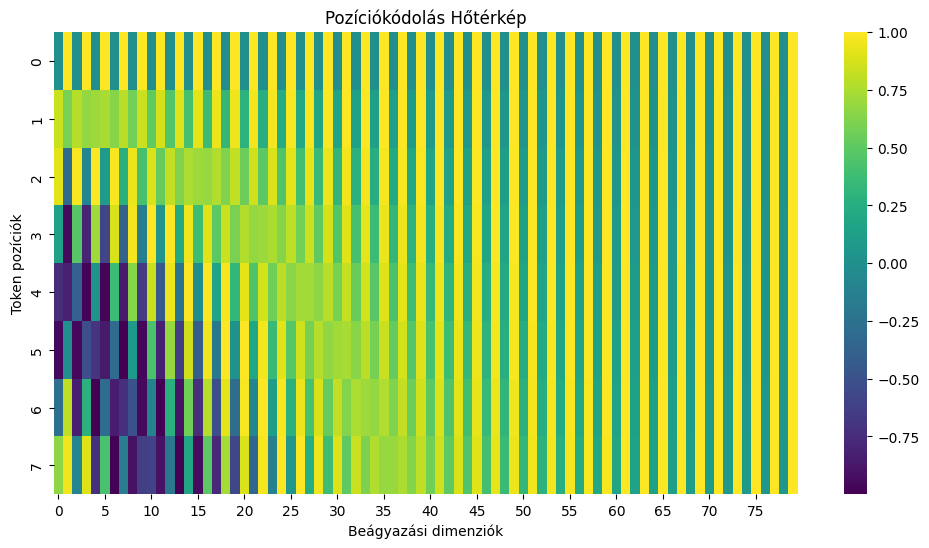

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pos_encoding[:, :80], cmap="viridis", xticklabels=5, yticklabels=1)
plt.xlabel("Beágyazási dimenziók")
plt.ylabel("Token pozíciók")
plt.title("Pozíciókódolás Hőtérkép")
plt.show()

## Tanítás

**Tanári kényszerítés (Teacher forcing)**: Az inferencia során a szöveggenerálás tokenről tokenre történik, ahol minden előrejelzett tokent bemenetként használunk a következő előrejelzéséhez. A tanítás során azonban egy **tanári kényszerítés** nevű technikát használunk a folyamat felgyorsítására és a tanulás javítására. A modell előzőleg előrejelzett tokenjei helyett a valódi (ground truth) értékeket használjuk bemenetként a következő előrejelzéséhez. Ez megakadályozza a hibaterjedést helytelen előrejelzések esetén, és segíti a modell hatékonyabb tanulását.

**Okozati maszkolás (Causal masking)**: A szekvencia következő tokenjének előrejelzésekor a modellnek csak az előtte lévő tokeneket szabad figyelembe vennie, az utána következőket nem. Ennek érvényesítéséhez **okozati maszkolást** (vagy **maszkolt önfigyelmet**) használunk **a dekóderben** a tanítás során. Ez biztosítja, hogy a modell minden tokent úgy jósol meg, hogy csak a szekvencia előző tokenjeit "látja". Ez a maszkolási mechanizmus kulcsfontosságú a modell auto-regresszív természetének fenntartásához és a jövőbeli tokenekből származó információszivárgás megakadályozásához.

<img src="https://raw.githubusercontent.com/TheBarbaraIsTaken/AIOlimpia-NLP/refs/heads/main/img/02_transformer_basics/mask.png" width="400">

Szókincs:
| Szavak: | \<SOS\> | \<EOS\> | brown | dog | fox | jumped | lazy | over | quick | the |  .  | \<PAD\> |
| :------ | :-----: | :-----: | :---: | :-: | :-: | :----: | :--: | :--: | :-:   | :-: | :-: | :--: |
| Id-k:   | 0       | 1       | 2     | 3   | 4   | 5      | 6    | 7    | 8     | 9   | 10  | 11  |

<br>

|szöveg:| \<SOS\> | the | quick | brown | fox | jumped | over | the | lazy | dog | .  | \<EOS\> |
|-------|---------|-----|-------|-------|-----|--------|------|-----|------|-----|----|---------|
|bemenet:| 0 | 9 | 8 | 2 | 4 | 5 | 7 | 9 | 6 | 3 | 10 | 1 |
|kimenet:| 9 | 8 | 2 | 4 | 5 | 7 | 9 | 6 | 3 | 10 | 1 | 11 |

## Transformer példa

Magyarról angolra fordítás. [Adatfeldolgozás forrása](https://pytorch.org/tutorials/beginner/torchtext_translation_tutorial.html).

### Adatok betöltése

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.n_words = 3  # SOS, EOS és PAD száma

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [ ]:
# Unicode string átalakítása sima ASCII-re, köszönet:
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Kisbetűssé alakítás, szóközök levágása és nem betű karakterek eltávolítása
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

In [ ]:
def readLangs(lang1, lang2, path, reverse=False):
    print("Sorok olvasása...")

    # Fájl beolvasása és sorokra bontása
    with open(path, encoding='utf-8') as file:
        lines = file.read().strip().split('\n')

    # Minden sor párokra bontása és normalizálása
    pairs = [[normalizeString(s) for s in l.split('\t')[:2]] for l in lines]

    # Párok megfordítása, Lang példányok létrehozása
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [ ]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re ",
)

def filterPair(p):
    return len(p[0].split(' ')) <= MAX_LENGTH and \
           len(p[1].split(' ')) <= MAX_LENGTH and \
           p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [ ]:
def prepareData(lang1, lang2, path, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, path, reverse)

    print("Beolvasva %s mondatpár" % len(pairs))
    pairs = filterPairs(pairs)

    print("Szűkítve %s mondatpárra" % len(pairs))
    print("Szavak számlálása...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])

    print("Megszámolt szavak:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)

    return input_lang, output_lang, pairs

In [ ]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('eng', 'hun', "hun.txt", True)

    n = len(pairs)
    input_ids = np.full((n, MAX_LENGTH+2), fill_value=PAD_token, dtype=np.int32)
    target_ids = np.full((n, MAX_LENGTH+2), fill_value=PAD_token, dtype=np.int32)

    inx = np.arange(len(pairs))
    np.random.shuffle(inx)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        inp_ids = [SOS_token] + inp_ids
        tgt_ids = [SOS_token] + tgt_ids
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_input_ids = input_ids[inx[:8000]]
    val_input_ids = input_ids[inx[8000:]]
    train_target_ids = target_ids[inx[:8000]]
    val_target_ids = target_ids[inx[8000:]]

    train_data = TensorDataset(torch.LongTensor(train_input_ids).to(device),
                               torch.LongTensor(train_target_ids).to(device))
    val_data = TensorDataset(torch.LongTensor(val_input_ids).to(device),
                               torch.LongTensor(val_target_ids).to(device))

    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

    return input_lang, output_lang, train_dataloader, val_dataloader

### Modell

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=15):
        super(PositionalEncoding, self).__init__()

        self.encoding = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1), :].to(x.device)

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_vocab_size, target_vocab_size, d_model=512, nhead=8, num_layers=3, dim_feedforward=2048):
        super(TransformerModel, self).__init__()
        self.d_model = d_model

        # Embedding layers
        self.input_embedding = nn.Embedding(input_vocab_size, d_model)
        self.target_embedding = nn.Embedding(target_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)

        # Transformer
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead, num_encoder_layers=num_layers,
            num_decoder_layers=num_layers, dim_feedforward=dim_feedforward, dropout=0.1
        )

        # Output layer
        self.fc_out = nn.Linear(d_model, target_vocab_size)

    def generate_square_subsequent_mask(self, length):
        mask = torch.triu(torch.ones(length, length) * float('-inf'), diagonal=1)
        return mask

    def forward(self, src, tgt):
        src_mask = None
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(src.device)

        src_emb = self.positional_encoding(self.input_embedding(src) * np.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.target_embedding(tgt) * np.sqrt(self.d_model))

        output = self.transformer(src_emb.transpose(0, 1), tgt_emb.transpose(0, 1), src_mask=src_mask, tgt_mask=tgt_mask)

        return self.fc_out(output.transpose(0, 1))


### Tanítás

In [ ]:
def evaluate(model, val_dataloader, criterion, device='cpu'):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for src, tgt in val_dataloader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            output = model(src, tgt_input)

            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()
            pred = output.argmax(2)
            correct += (pred == tgt_output).sum().item()
            total += tgt_output.numel()

    val_loss = total_loss / len(val_dataloader)
    val_acc = correct / total

    # print(f"Validációs veszteség: {val_loss:.4f}, Pontosság: {val_acc:.4f}")
    return val_loss, val_acc

In [ ]:
def train(model, train_dataloader, val_dataloader, optimizer, criterion, num_epochs=10, device="cpu", print_every=100):
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for src, tgt in train_dataloader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]  # Dekóder bemenet
            tgt_output = tgt[:, 1:]  # Valós érték (ground truth)

            optimizer.zero_grad()
            output = model(src, tgt_input)

            # Veszteség számítása
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validáció
        val_loss, val_acc = evaluate(model, val_dataloader, criterion, device=device)

        val_losses.append(val_loss)
        train_losses.append(total_loss / len(train_dataloader))

        if (epoch+1) % print_every == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Veszteség: {total_loss/len(train_dataloader):.4f} - Val veszteség: {val_loss:.4f} - Val pontosság: {val_acc:.4f}")

    return train_losses, val_losses

In [ ]:
batch_size = 512

input_lang, output_lang, train_dataloader, val_dataloader = get_dataloader(batch_size)

Sorok olvasása...
Beolvasva 121549 mondatpár
Szűkítve 8521 mondatpárra
Szavak számlálása...
Megszámolt szavak:
hun 6195
eng 2728


In [ ]:
# Eszköz definiálása
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modell példányosítása
model = TransformerModel(
    input_vocab_size=input_lang.n_words,
    target_vocab_size=output_lang.n_words,
    d_model=512,  # Csökkentve a gyorsabb tanítás érdekében
    nhead=8,
    num_layers=5,
    dim_feedforward=512  # Egyszerűsítés érdekében csökkentve
).to(device)

# Optimalizáló és veszteségfüggvény definiálása
padding_id = PAD_token

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00001)
criterion = nn.CrossEntropyLoss(ignore_index=padding_id)
NUM_EPOCHS = 50

train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, num_epochs=NUM_EPOCHS, device=device, print_every=10)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 10/50, Veszteség: 4.6878 - Val veszteség: 4.7883 - Val pontosság: 0.2270
Epoch 20/50, Veszteség: 3.9384 - Val veszteség: 3.7992 - Val pontosság: 0.2603
Epoch 30/50, Veszteség: 3.5625 - Val veszteség: 3.3779 - Val pontosság: 0.2771
Epoch 40/50, Veszteség: 3.3263 - Val veszteség: 3.1804 - Val pontosság: 0.2874
Epoch 50/50, Veszteség: 3.1366 - Val veszteség: 3.0446 - Val pontosság: 0.2998


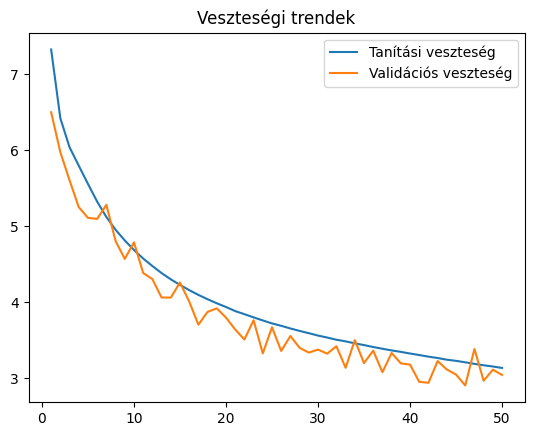

In [ ]:
epochs = range(1, NUM_EPOCHS+1)
plt.plot(epochs, train_losses, label="Tanítási veszteség")
plt.plot(epochs, val_losses, label="Validációs veszteség")
plt.legend()
plt.title("Veszteségi trendek")
plt.show()

### Modell mentése és betöltése

In [ ]:
file_path = "trained_transformer_model.pth"

In [ ]:
torch.save(model.state_dict(), file_path)

In [ ]:
model_loaded = TransformerModel(
    input_vocab_size=input_lang.n_words,
    target_vocab_size=output_lang.n_words,
    d_model=512,  # Reduce for faster training
    nhead=8,
    num_layers=5,
    dim_feedforward=512  # Reduced for simplicity
).to(device)
model_loaded.load_state_dict(torch.load(file_path, weights_only=True))
model_loaded.eval()

TransformerModel(
  (input_embedding): Embedding(6195, 512)
  (target_embedding): Embedding(2728, 512)
  (positional_encoding): PositionalEncoding()
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-4): 5 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): T

### Tesztelés

In [ ]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = [SOS_token] + indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def translate(model, sentence, input_lang, output_lang):
    model.eval()

    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence).to(device)
        tgt_input = torch.tensor([SOS_token], dtype=torch.long).unsqueeze(0).to(device)

        for _ in range(15):
            output = model(input_tensor, tgt_input)
            next_token = output.argmax(2)[:, -1:]
            tgt_input = torch.cat((tgt_input, next_token), dim=1)

            if next_token.item() == EOS_token:
                break

        translated_text = ' '.join(output_lang.index2word[idx.item()] for idx in tgt_input[0, 1:-1])
        return translated_text

print(translate(model_loaded, "itt vagyok", input_lang, output_lang))
print(translate(model_loaded, "itt vagyunk", input_lang, output_lang))
print(translate(model_loaded, "nagy vagy", input_lang, output_lang))
print(translate(model_loaded, "nagyon nagy vagy", input_lang, output_lang))
print(translate(model_loaded, "te nagyon kicsi vagy", input_lang, output_lang))

i m sure you re here here
you re here to here here here
you re a you re a you re the only one the only
you re very very very very you re a you re a you
you re very very very very very very you
